# Analisis Penjualan Supermarket

Project ini bertujuan untuk menganalisis data penjualan supermarket menggunakan Python, Pandas, dan Matplotlib.

## Analisis yang dilakukan
- Statistik dasar data penjualan
- Total sales berdasarkan product line
- Tren sales berdasarkan bulan
- Total sales berdasarkan branch
- Distribusi metode pembayaran
- Hubungan rating dengan sales
- Rata-rata sales berdasarkan product line

## 1. Import dan Membaca Data

Dataset dibaca menggunakan Pandas untuk mempersiapkan data sebelum dilakukan proses analisis.

In [81]:
import pandas as pd

df = pd.read_csv("../Data/SuperMarket Analysis.csv")

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


## 2. Pemeriksaan Data

Pemeriksaan dilakukan untuk melihat informasi dasar dataset, jumlah data, nama kolom, tipe data, dan statistik deskriptif.

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [83]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [84]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [85]:
df.shape

(1000, 17)

In [86]:
df.dtypes

Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

## 3. Data Cleaning

Kolom Date dikonversi ke tipe datetime agar dapat digunakan untuk analisis berdasarkan waktu.

In [87]:
df["Date"] = pd.to_datetime(df["Date"])

In [88]:
df.dtypes

Invoice ID                         object
Branch                             object
City                               object
Customer type                      object
Gender                             object
Product line                       object
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Sales                             float64
Date                       datetime64[ns]
Time                               object
Payment                            object
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
dtype: object

## 4. Analisis Penjualan

Analisis dilakukan untuk melihat pola penjualan berdasarkan product line, bulan, branch, metode pembayaran, serta hubungan antara rating dan sales.

In [89]:
df.groupby("Product line")["Sales"].sum().sort_values(ascending=False)

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64

## 5. Visualisasi Data

Visualisasi digunakan untuk menyajikan hasil analisis dalam bentuk grafik agar pola dan perbandingan data lebih mudah dipahami.

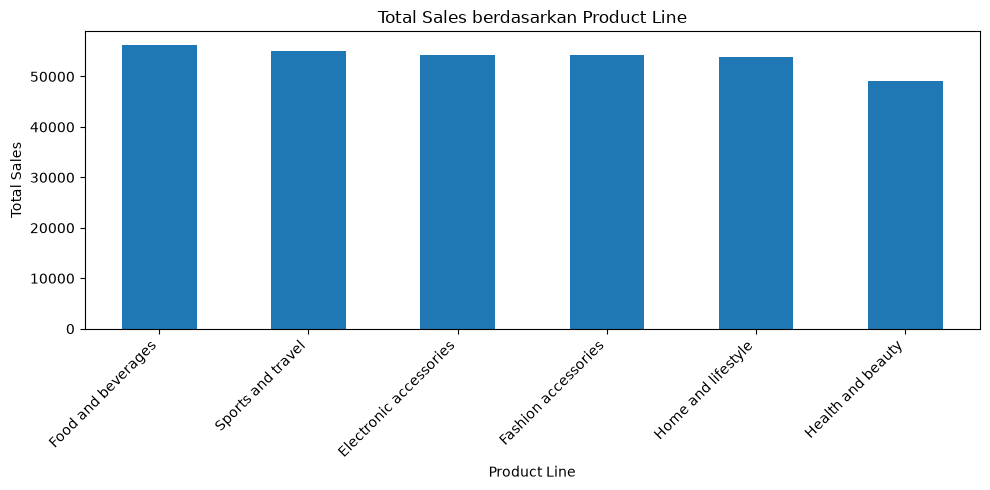

In [90]:
import matplotlib.pyplot as plt

sales_by_product = df.groupby("Product line")["Sales"].sum().sort_values(ascending=False)

sales_by_product.plot(kind="bar", figsize=(10, 5))

plt.title("Total Sales berdasarkan Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../Visualizations/sales_by_product.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.2 Tren Penjualan Bulanan

Analisis ini digunakan untuk melihat perubahan total sales dari bulan ke bulan.

In [91]:
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Sales"].sum()

monthly_sales

Date
2019-01    116291.868
2019-02     97219.374
2019-03    109455.507
Freq: M, Name: Sales, dtype: float64

### 5.2 Tren Total Sales per Bulan

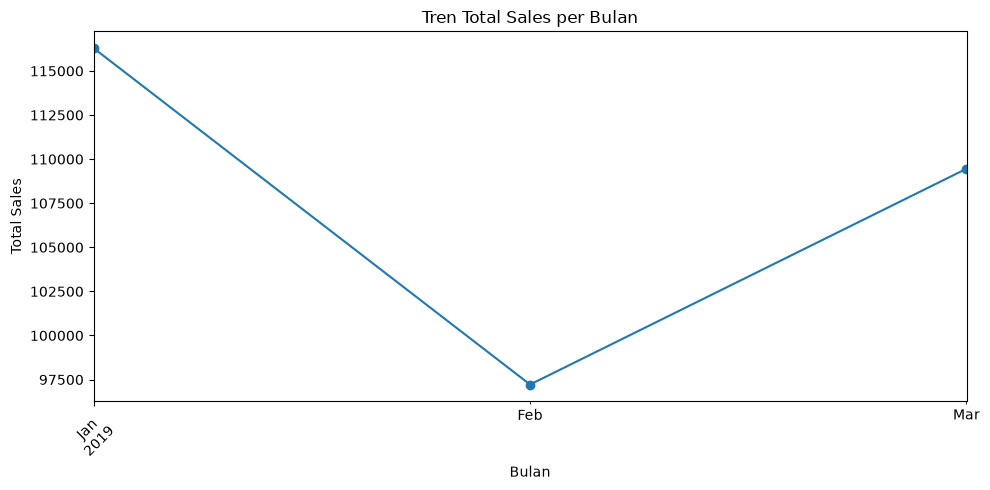

In [92]:
monthly_sales.plot(kind="line", marker="o", figsize=(10, 5))

plt.title("Tren Total Sales per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../Visualizations/monthly_sales_trend.png", dpi=300, bbox_inches="tight")

plt.show()

### 4.3 Penjualan berdasarkan Branch

Analisis ini digunakan untuk membandingkan total sales pada setiap branch.

In [93]:
sales_by_branch = df.groupby("Branch")["Sales"].sum().sort_values(ascending=False)

sales_by_branch

Branch
Giza     110568.7065
Alex     106200.3705
Cairo    106197.6720
Name: Sales, dtype: float64

### 5.3 Total Sales berdasarkan Branch

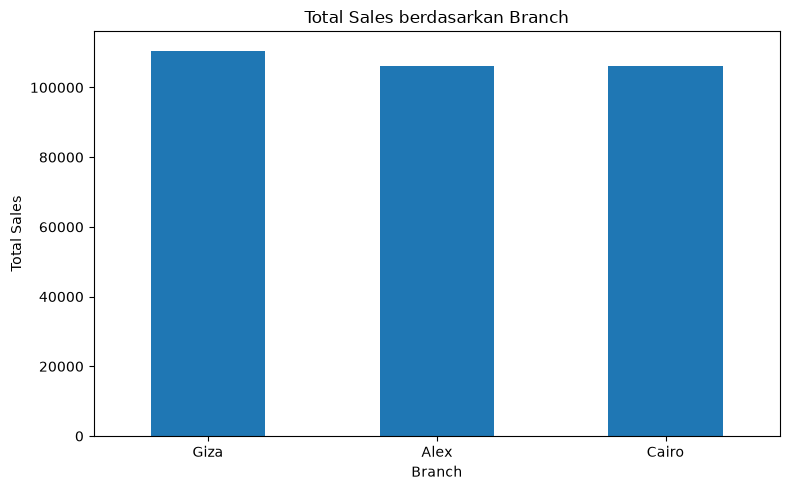

In [94]:
sales_by_branch.plot(kind="bar", figsize=(8, 5))

plt.title("Total Sales berdasarkan Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../Visualizations/sales_by_branch.png", dpi=300, bbox_inches="tight")

plt.show()

### 4.4 Metode Pembayaran

Analisis ini digunakan untuk melihat jumlah transaksi berdasarkan metode pembayaran yang digunakan.

In [95]:
payment_counts = df["Payment"].value_counts()

payment_counts

Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64

### 5.4 Jumlah Transaksi berdasarkan Metode Pembayaran

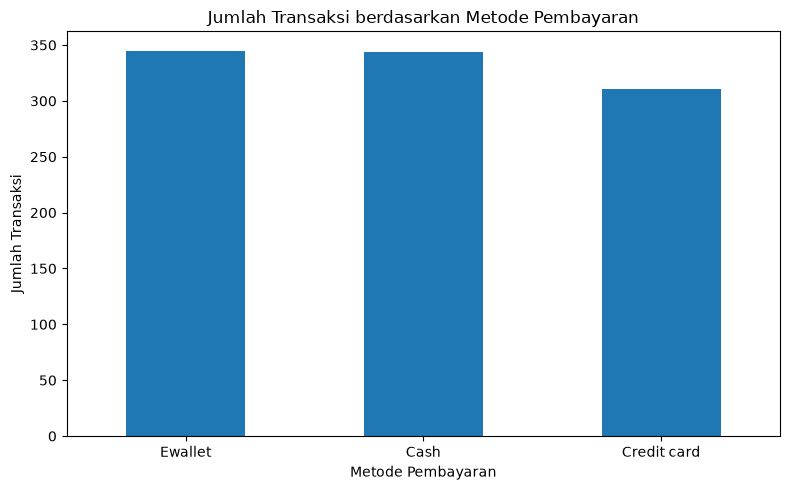

In [96]:
payment_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Jumlah Transaksi berdasarkan Metode Pembayaran")
plt.xlabel("Metode Pembayaran")
plt.ylabel("Jumlah Transaksi")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../Visualizations/payment_method.png", dpi=300, bbox_inches="tight")

plt.show()

### 4.5 Hubungan Rating dan Sales

Analisis ini digunakan untuk melihat hubungan antara rating pelanggan dan nilai sales.

In [97]:
df[["Rating", "Sales"]].corr()

,Rating,Sales
Rating,1.000000,-0.036442
Sales,-0.036442,1.000000


### 5.5 Hubungan Rating dan Sales

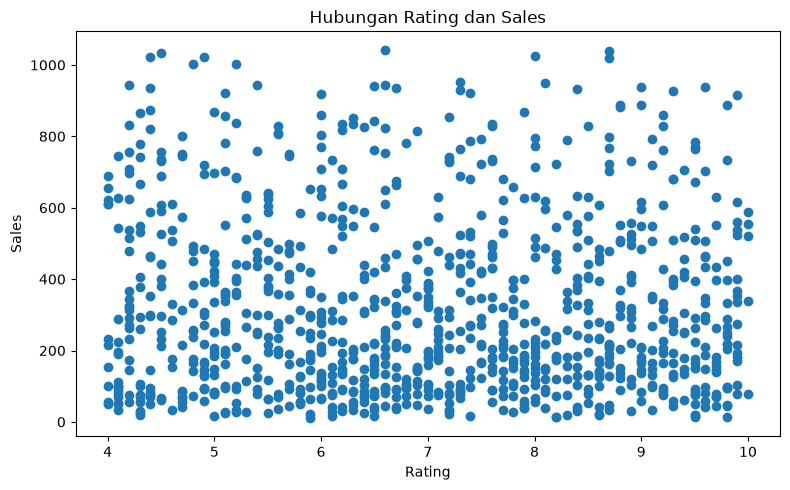

In [98]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Rating"], df["Sales"])

plt.title("Hubungan Rating dan Sales")
plt.xlabel("Rating")
plt.ylabel("Sales")
plt.tight_layout()

plt.savefig("../Visualizations/rating_vs_sales.png", dpi=300, bbox_inches="tight")

plt.show()

### 4.6 Rata-rata Sales berdasarkan Product Line

Analisis ini digunakan untuk melihat rata-rata nilai sales pada setiap product line.

In [99]:
avg_sales_by_product = df.groupby("Product line")["Sales"].mean().sort_values(ascending=False)

avg_sales_by_product

Product line
Home and lifestyle        336.636956
Sports and travel         332.065220
Health and beauty         323.643020
Food and beverages        322.671517
Electronic accessories    319.632538
Fashion accessories       305.089298
Name: Sales, dtype: float64

### 5.6 Rata-rata Sales berdasarkan Product Line

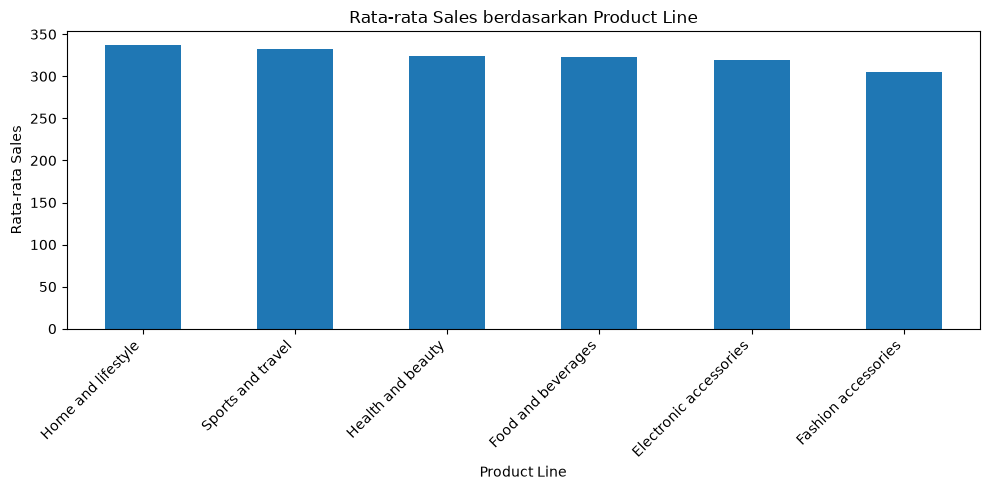

In [100]:
avg_sales_by_product.plot(kind="bar", figsize=(10, 5))

plt.title("Rata-rata Sales berdasarkan Product Line")
plt.xlabel("Product Line")
plt.ylabel("Rata-rata Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("../Visualizations/avg_sales_by_product.png", dpi=300, bbox_inches="tight")

plt.show()

## 6. Kesimpulan

Berdasarkan hasil analisis, data penjualan supermarket terdiri dari 1.000 transaksi dengan total sales sebesar 322.966,75. Analisis menunjukkan perbedaan sales berdasarkan product line, branch, bulan, dan metode pembayaran. Visualisasi digunakan untuk membantu melihat pola dan perbandingan dari hasil analisis tersebut.

In [101]:
summary = {
    "Total Sales": df["Sales"].sum(),
    "Rata-rata Sales": df["Sales"].mean(),
    "Total Transaksi": df["Invoice ID"].nunique(),
    "Rata-rata Rating": df["Rating"].mean(),
    "Total Quantity": df["Quantity"].sum()
}

summary

{'Total Sales': np.float64(322966.749),
 'Rata-rata Sales': np.float64(322.966749),
 'Total Transaksi': 1000,
 'Rata-rata Rating': np.float64(6.9727),
 'Total Quantity': np.int64(5510)}